# Fitting PTT model to HA Rheological Data

BIEN 514 Final Project

Winter 2026

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [105]:
def ptt_maxwell(omega, *params):
    """
    SAOS simplified PTT model into multimode Maxwell model

    Parameters
    ----------
        omega : shear frequency
        params : flast list of G and lambda [G1, L1 ... Gn, Ln]
    """
    
    n_modes = len(params) // 2
    G_modes = params[::2]
    L_modes = params[1::2]

    G_storage = np.zeros_like(omega)
    G_loss = np.zeros_like(omega)

    for i in range(n_modes):
        Gi = G_modes[i]
        Li = L_modes[i]

        denom = 1 + (omega * Li)**2
        G_storage += (Gi * ((omega * Li)**2)) / denom
        G_loss += (Gi * omega * Li) / denom

    return np.concatenate([G_storage, G_loss])

## Testing

In [ ]:
# Define Ground Truth Parameters (3 Modes)
# Format: [G1, L1, G2, L2, G3, L3]
true_params = [
    5000, 0.01,  # Mode 1: Fast relaxation, high modulus
    1000, 0.1,   # Mode 2: Intermediate
    200,  1.0    # Mode 3: Slow relaxation, low modulus
]

# Frequency range (logarithmically spaced)
omega_test = np.logspace(-2, 2, 50) 

def generate_test_data(omega, params):
    g_prime = np.zeros_like(omega)
    g_double_prime = np.zeros_like(omega)
    for i in range(len(params) // 2):
        Gi, Li = params[2*i], params[2*i+1]
        denom = 1 + (omega * Li)**2
        g_prime += (Gi * (omega * Li)**2) / denom
        g_double_prime += (Gi * (omega * Li)) / denom
    return g_prime, g_double_prime

# Generate the arrays
Gp_test, Gpp_test = generate_test_data(omega_test, true_params)

# Optional: Add 2% random noise to simulate real rheometer data
np.random.seed(42)
Gp_test *= (1 + 0.02 * np.random.randn(len(omega_test)))
Gpp_test *= (1 + 0.02 * np.random.randn(len(omega_test)))

In [139]:
combined = np.concatenate([Gp_test, Gpp_test])

initial = [
    4000, 0.03,  # Mode 1: Fast relaxation, high modulus
    1200, 0.05,   # Mode 2: Intermediate
    250,  0.9    # Mode 3: Slow relaxation, low modulus
]

popt, _ = curve_fit(ptt_maxwell, omega_test, combined, initial)

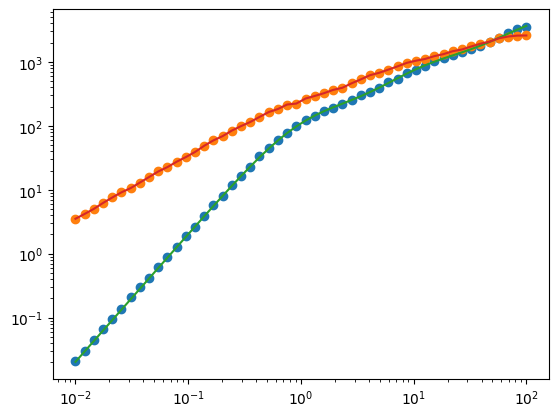

In [140]:
test = ptt_maxwell(omega_test, *popt)

G_loss = test[:len(omega_test)]

plt.loglog(omega_test, Gp_test, 'o')
plt.loglog(omega_test, Gpp_test, 'o')
plt.loglog(omega_test, G_loss)
plt.loglog(omega_test, Gpp_test)

## Fitting Experimental Data

In [185]:
saos640 = pd.read_excel("SAOS.xlsx", sheet_name='640 kDa')
saos1060 = pd.read_excel("SAOS.xlsx", sheet_name='1060 kDa')
saos2010 = pd.read_excel("SAOS.xlsx", sheet_name='2010 kDa')

steady640 = pd.read_excel("SteadyShear.xlsx", sheet_name='640 kDa')
steady1060 = pd.read_excel("SteadyShear.xlsx", sheet_name='1060 kDa')
steady2010 = pd.read_excel("SteadyShear.xlsx", sheet_name='2010 kDa')

### 640 kDa

In [259]:
def ptt_fit(data):
    combined = data[['Storage', 'Loss']].values.flatten('F')

    initial = [
        0.1, 1,   # Mode 2: Intermediate
        10, 0.1,  # Mode 1: Fast relaxation, high modulus
        100,  0.01    # Mode 3: Slow relaxation, low modulus
    ]

    popt, _ = curve_fit(ptt_maxwell, data['Frequency'], combined, initial, sigma=combined)
    fit = ptt_maxwell(data['Frequency'], *popt)
    data['Storage Fit'] = fit[:data.shape[0]]
    data['Loss Fit'] = fit[data.shape[0]:]

    return popt

In [273]:
params640 = ptt_fit(saos640)
params1060 = ptt_fit(saos1060)
params2010 = ptt_fit(saos2010)

In [328]:
def plot_fit(ax, data, weight:str):
    ax.scatter(data['Frequency'], data['Storage'], label="Measured G'")
    ax.scatter(data['Frequency'], data['Loss'], label='Measured G"')

    ax.plot(data['Frequency'], data['Storage Fit'], label="Fitted G'")
    ax.plot(data['Frequency'], data['Loss Fit'], label='Fitted G"')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Storage and Loss Moduli (Pa)')
    ax.set_title(weight)

    ax.legend(ncols=2, loc='lower right')

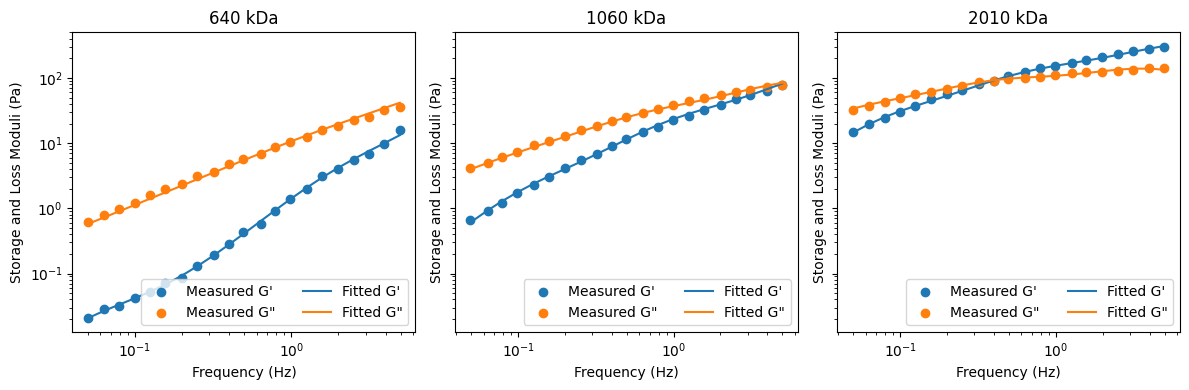

In [330]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

plot_fit(ax[0], saos640, '640 kDa')
plot_fit(ax[1], saos1060, '1060 kDa')
plot_fit(ax[2], saos2010, '2010 kDa')

fig.tight_layout()
fig.savefig('saos.svg')